In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import csv


In [2]:

with open('./database/edges.csv', mode='r') as file:
    edges = pd.read_csv(file)

with open('./database/stations.csv', mode='r') as file:
    stations = pd.read_csv(file)

with open("./database/routes.tsv", newline='') as file:
    reader = csv.reader(file, delimiter='\t')
    routes = [row for row in reader]



In [3]:
print(routes[:5])

[['SVG', 'WAS', 'HFN', 'BAY', 'CUF', 'CWH', 'GDH', 'ENC', 'GPK', 'WIH', 'PAL', 'BOP', 'AAP', 'HRN', 'HGY', 'FPK', 'KGX'], ['KGX', 'FPK', 'HGY', 'HRN', 'AAP', 'BOP', 'PAL', 'WIH', 'GPK', 'ENC', 'GDH', 'CWH', 'CUF', 'BAY', 'HFN', 'WAS', 'SVG'], ['SVG', 'WAS', 'HFN', 'BAY', 'CUF', 'CWH', 'GDH', 'ENC', 'GPK', 'WIH', 'PAL', 'BOP', 'AAP', 'HRN', 'HGY', 'FPK', 'KGX'], ['KGX', 'FPK', 'HGY', 'HRN', 'AAP', 'BOP', 'PAL', 'WIH', 'GPK', 'ENC', 'GDH', 'CWH', 'CUF', 'BAY', 'HFN', 'WAS', 'SVG'], ['SVG', 'WAS', 'HFN', 'BAY', 'CUF', 'CWH', 'GDH', 'ENC', 'GPK', 'WIH', 'PAL', 'BOP', 'AAP', 'HRN', 'HGY', 'FPK', 'KGX']]


In [4]:
clean_routes = []
for row in routes:
    if row not in clean_routes:
        clean_routes.append(row)
print(clean_routes[:5])

[['SVG', 'WAS', 'HFN', 'BAY', 'CUF', 'CWH', 'GDH', 'ENC', 'GPK', 'WIH', 'PAL', 'BOP', 'AAP', 'HRN', 'HGY', 'FPK', 'KGX'], ['KGX', 'FPK', 'HGY', 'HRN', 'AAP', 'BOP', 'PAL', 'WIH', 'GPK', 'ENC', 'GDH', 'CWH', 'CUF', 'BAY', 'HFN', 'WAS', 'SVG'], ['KGX', 'FPK', 'HGY', 'HRN', 'AAP', 'NSG', 'OKL', 'NBA', 'HDW', 'PBR', 'BPK', 'WMG', 'HAT', 'WGC'], ['WGC', 'HAT', 'WMG', 'BPK', 'PBR', 'HDW', 'NBA', 'OKL', 'NSG', 'AAP', 'HRN', 'HGY', 'FPK', 'KGX'], ['PPD', 'ACY', 'PER', 'MTA', 'FER', 'CMH', 'ABA']]


In [5]:
edges.describe(include="object")

,source,target
count,7636,7636
unique,2556,2556
top,LDS,BHM
freq,24,24


In [6]:
edges.describe()

,distance
count,7636.000000
mean,10.464650
std,21.717175
min,0.000000
25%,2.280000
50%,4.750000
75%,10.432500
max,531.380000


In [7]:
edges.sort_values("distance")

,source,target,distance
4253,LST,LST,0.00
4832,NLR,LWR,0.04
4320,LWR,NLR,0.04
525,BFR,CTK,0.24
1727,CTK,BFR,0.24
...,...,...,...
4778,NCL,SVG,353.64
5322,PRE,KIN,378.98
4773,NCL,KGX,395.03
3702,KGX,NCL,395.03


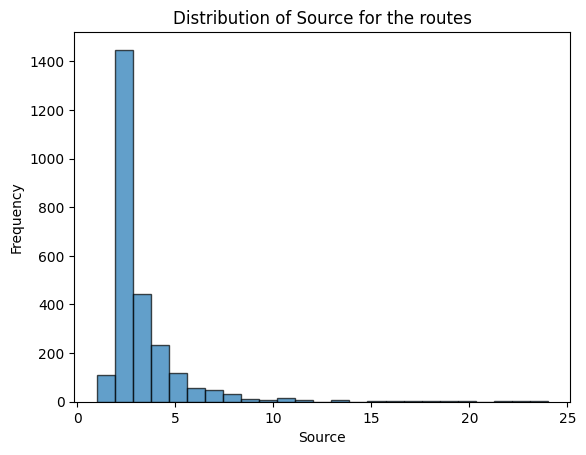

In [8]:
edges['source'].value_counts().plot(kind='hist', bins=25, edgecolor='black', alpha=0.7)
plt.title('Distribution of Source for the routes')
plt.xlabel('Source')
plt.ylabel('Frequency')
plt.show()


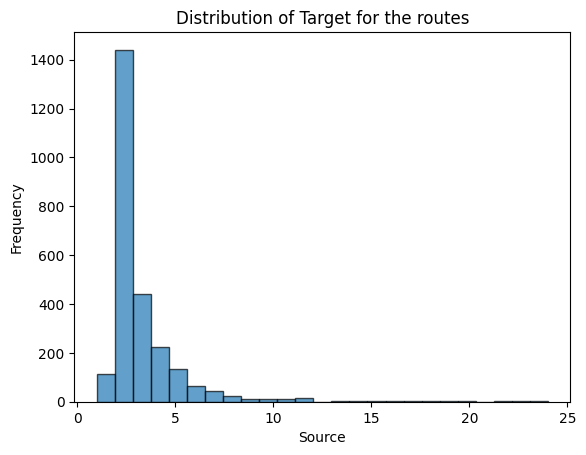

In [9]:
edges['target'].value_counts().plot(kind='hist', bins=25, edgecolor='black', alpha=0.7)
plt.title('Distribution of Target for the routes')
plt.xlabel('Source')
plt.ylabel('Frequency')
plt.show()


In [10]:
edges = edges.merge(stations, left_on="source", right_on="code", how="left" )
edges = edges.merge(stations, left_on="target", right_on="code", how="left", suffixes=("_source", "_target"))

edges = edges.drop(columns=['code_source', 'code_target'])

## Analysis of the routes

In [11]:
from collections import Counter

# Suppose routes is a list of lists like:
# [['SVG', 'WAS', 'HFN'], ['HFN', 'BAY'], ['SVG', 'BAY']]

# Flatten it
flat = [station for route in routes for station in route]

# Count frequencies
freq = Counter(flat)

# Show top 10 most common stations
print(freq.most_common(10))


[('CLJ', 4404), ('LST', 3286), ('LBG', 3007), ('ZLW', 2972), ('ZFD', 2908), ('SRA', 2781), ('WAT', 2671), ('PAD', 2356), ('HHY', 2343), ('GLC', 2179)]


In [12]:
freq_df = pd.DataFrame(freq.items(), columns=['station', 'count'])
freq_df = freq_df.sort_values('count', ascending=False)
freq_df.reset_index()
print(freq_df.head())


    station  count
309     CLJ   4404
123     LST   3286
472     LBG   3007
124     ZLW   2972
122     ZFD   2908


In [13]:
freq_df = freq_df.merge(stations, left_on="station", right_on="code", how="left" )
freq_df.head()

,station,count,code,lat,long,name
0,CLJ,4404,CLJ,51.464191,-0.170247,Clapham Junction
1,LST,3286,LST,51.518023,-0.081996,London Liverpool Street
2,LBG,3007,LBG,51.505096,-0.085060,London Bridge
3,ZLW,2972,ZLW,51.519467,-0.059757,Whitechapel
4,ZFD,2908,ZFD,51.520530,-0.105040,Farringdon


<Figure size 1000x500 with 0 Axes>

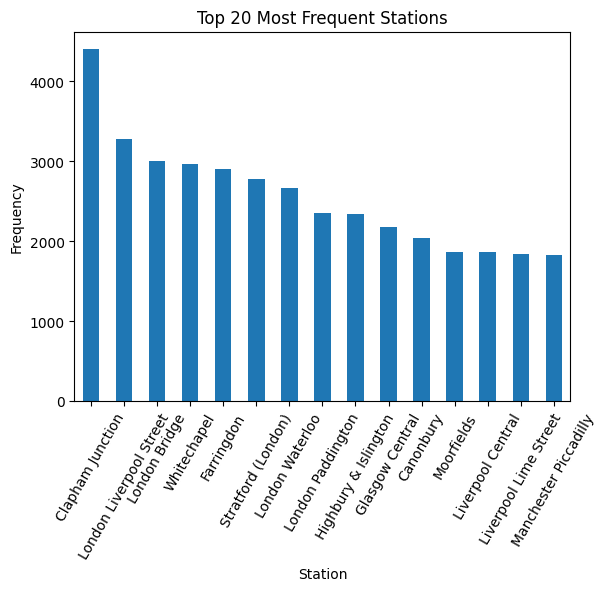

In [14]:
import matplotlib.pyplot as plt

plt.figure(figsize=(10,5))
freq_df.head(15).plot(kind='bar', x='name', y='count', legend=False)
plt.title("Top 20 Most Frequent Stations")
plt.xlabel("Station")
plt.ylabel("Frequency", loc='center')
plt.xticks(rotation=60)
plt.show()


In [51]:
import plotly.express as px

freq_df["size"] = freq_df["count"]/max(freq_df["count"])
fig = px.scatter_map(freq_df,
                    lat="lat",
                    lon="long",
                    size="size",
    )

fig.update_layout(
    
    height=600,
    map_style="open-street-map",
    geo=dict(
        center=dict(
            lat=54.5057,
            lon=-1.7274
        ),
    )
)

fig.update_layout(margin={"r":0,"t":0,"l":0,"b":0})
fig.show()